In [35]:
#!python src/scaledetection.py --model models/yolov8m_train/weights/best.pt --image_dir data/annot --plot
import json
import os
from pathlib import Path
import sys

import numpy as np
import pandas as pd

sys.path.append(str(Path(os.path.abspath(".")) / "src"))
from src.scaledetection import main as scale_detection_main


%load_ext autoreload
%autoreload 2

_prev_argv = sys.argv
sys.argv = [
	'scaledetection',
	'--model', 'models/yolov8m_train/weights/best.pt',
	'--image_dir', 'data/annot.nosync',
	'--plot'
]
try:
	scale_results = scale_detection_main()
finally:
	sys.argv = _prev_argv

scale_results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Processing images:  43%|████▎     | 280/654 [07:16<09:00,  1.44s/it]/Users/emmaboehly/Documents/Vector/ScaleDetection/src/atypical_scalebars.py:23: RuntimeWarning: divide by zero encountered in divide
  import matplotlib.pyplot as plt
Processing images: 100%|██████████| 654/654 [24:20<00:00,  2.23s/it]


In [15]:
# Load ground_truth_annotations.csv
ground_truth = pd.read_csv('data/ground_truth_annotations.csv', usecols=['image', 'label', 'unit', 'value'])

# Extract image names
ground_truth['image'] = ground_truth['image'].apply(lambda x: x.split('/')[-1].replace('.jpg', ''))
ground_truth.set_index('image', inplace=True)

# Get approximate bar size
def get_bar_size(row):
    if pd.isnull(row['label']):
        return pd.Series(None)
    for item in np.array(eval(row['label'])):
        if item['rectanglelabels'] == ['bar']:
            if item['width'] > item['height']:
                return pd.Series(item['width'] * item['original_width'] / 100)
            else:
                return pd.Series(item['height'] * item['original_height'] / 100)
    return pd.Series(None)
ground_truth['bar_size'] = ground_truth.apply(get_bar_size, axis=1)

# Load predictions
dfs = []
for filename in os.listdir('outputs/'):
    if filename.endswith('.json'):
        with open(os.path.join('outputs/', filename), 'r') as f:
            data = json.load(f)
            df = pd.json_normalize(data)
            df['image'] = filename.removesuffix('.json')
            dfs.append(df)

predictions = pd.concat(dfs, ignore_index=True).set_index('image')

# Merge ground truth and predictions
merged = pd.merge(ground_truth, predictions, left_index=True, right_index=True, how='outer')

# Check if some images have no scale bar detected
merged[merged['scale_bar_found'].isnull()]

/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_45943/1719212303.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  predictions = pd.concat(dfs, ignore_index=True).set_index('image')


,label,unit,value,bar_size,scale_bar_found,measured_scale_length,declared_scale_length,units,pixel_to_mm_ratio,orientation,scale_bar_confidence,scale_length_flag,text_label_confidence,orientation_confidence,type_
image,,,,,,,,,,,,,,,


In [16]:
# Compare ground truth and predictions
detection = merged
recognition = detection[detection['label'].notnull()]

results = {
    'total_images': len(detection),
    'correct_detections': (detection['scale_bar_found'] == detection['label'].notnull()).mean(),
    'correct_labels_values': (recognition['declared_scale_length'] == recognition['value']).mean(),
    'correct_labels_units': (recognition['units'] == recognition['unit']).mean(),
    'correct_labels' : ((recognition['declared_scale_length'] == recognition['value']) & (recognition['units'] == recognition['unit'])).mean(),
    'correct_bar_size': (np.abs(recognition['measured_scale_length'] - recognition['bar_size']) / recognition['bar_size'] <= 0.05).mean(),
    'bar_size_MAE': np.mean(np.abs(recognition['measured_scale_length'] - recognition['bar_size'])),
    'bar_size_normalized_MAE': np.mean(np.abs(recognition['measured_scale_length'] - recognition['bar_size']) / recognition['bar_size']),
}
results

{'total_images': 654,
 'correct_detections': np.float64(1.0),
 'correct_labels_values': np.float64(1.0),
 'correct_labels_units': np.float64(1.0),
 'correct_labels': np.float64(1.0),
 'correct_bar_size': np.float64(0.9801324503311258),
 'bar_size_MAE': np.float64(4.949479009617086),
 'bar_size_normalized_MAE': np.float64(0.012097678633953429)}

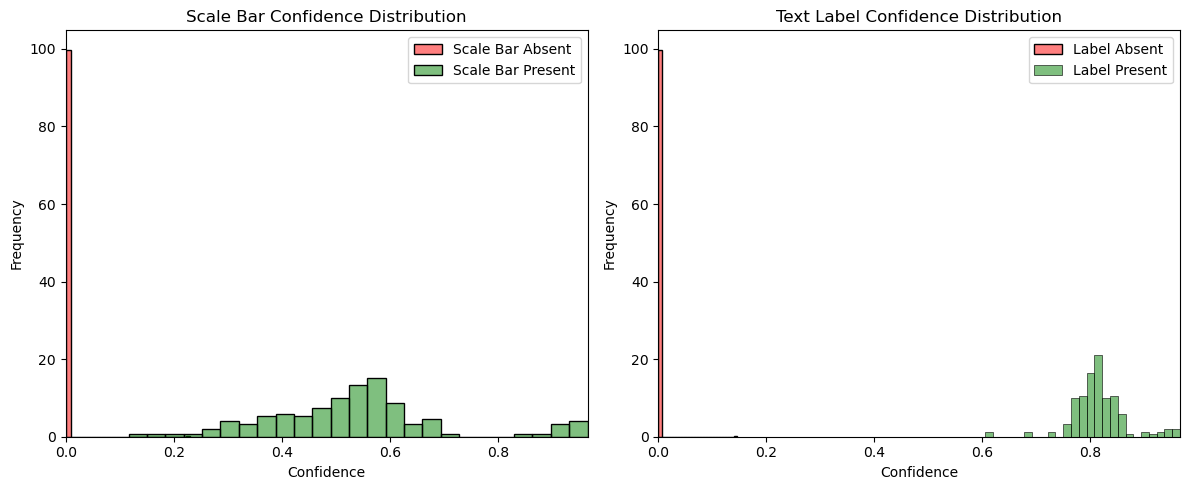

In [17]:
# Visualize confidence distributions
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(np.array(detection[detection['label'].isnull()]['scale_bar_confidence']), stat='percent', bins=25, color='red', alpha=0.5, label='Scale Bar Absent')
sns.histplot(np.array(detection[detection['label'].notnull()]['scale_bar_confidence']), stat='percent', bins=25, color='green', alpha=0.5, label='Scale Bar Present')
plt.legend()
plt.title('Scale Bar Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.xlim(np.min(detection['scale_bar_confidence']), np.max(detection['scale_bar_confidence']))
plt.subplot(1, 2, 2)
sns.histplot(np.array(detection[detection['value'].isnull() | (detection['value'] == 0)]['text_label_confidence']), stat='percent', bins=25, color='red', alpha=0.5, label='Label Absent')
sns.histplot(np.array(detection[detection['value'].notnull() & (detection['value'] > 0)]['text_label_confidence']), stat='percent', bins=25, color='green', alpha=0.5, label='Label Present')
plt.legend()
plt.title('Text Label Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.xlim(np.min(detection['text_label_confidence']), np.max(detection['text_label_confidence']))
plt.tight_layout()
plt.show()

Number of error cases: 3 out of 654
Image: BIOUG85754-A12.3b8e9942, Scale Bar Found: True, Label Present: True, Scale Type: ruler_photo


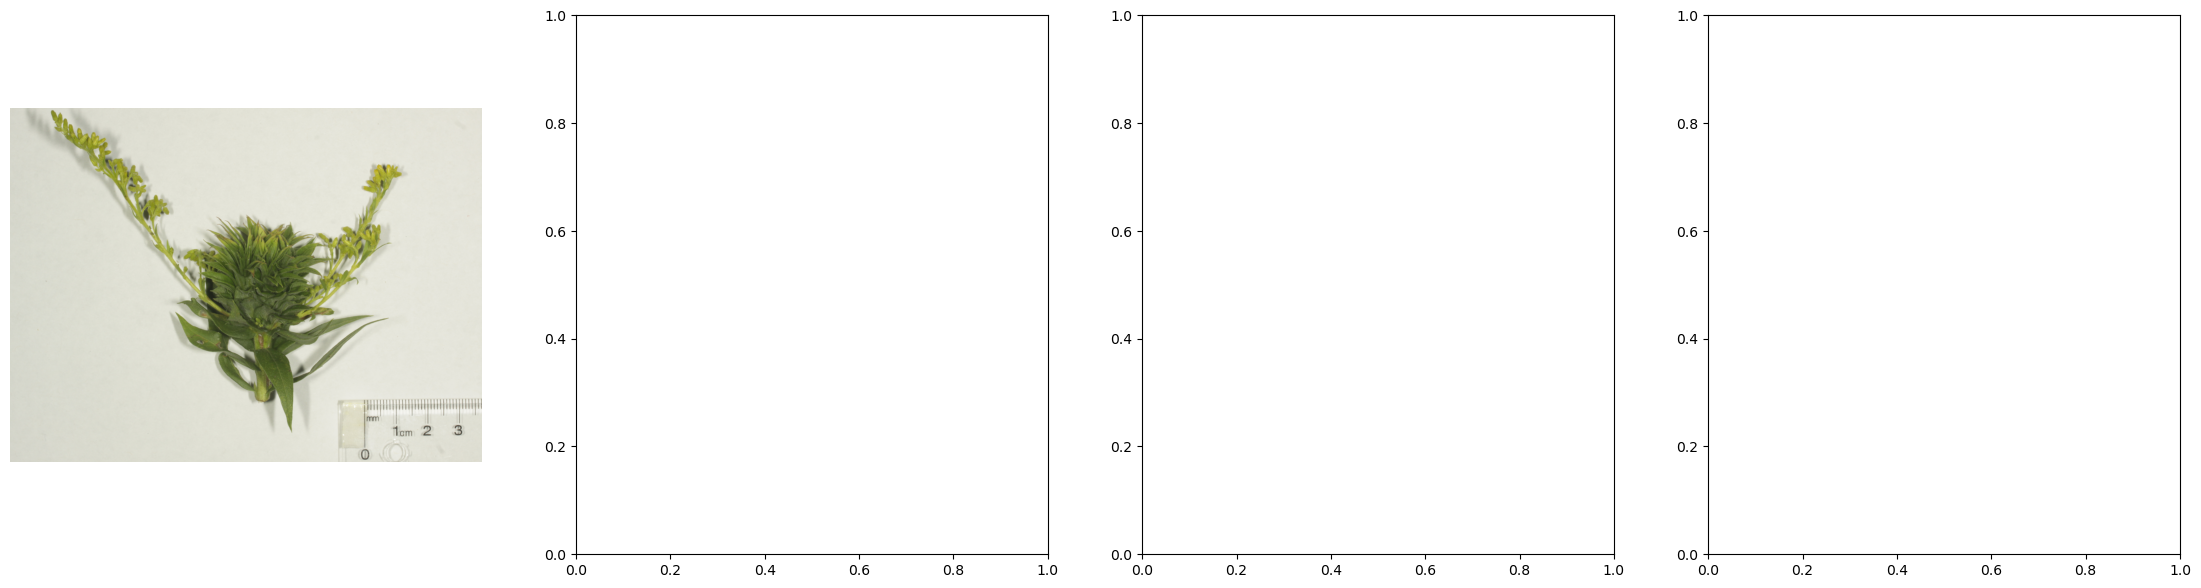

Image: BIOUG85754-C04.a85fdd1e, Scale Bar Found: True, Label Present: True, Scale Type: ruler_photo


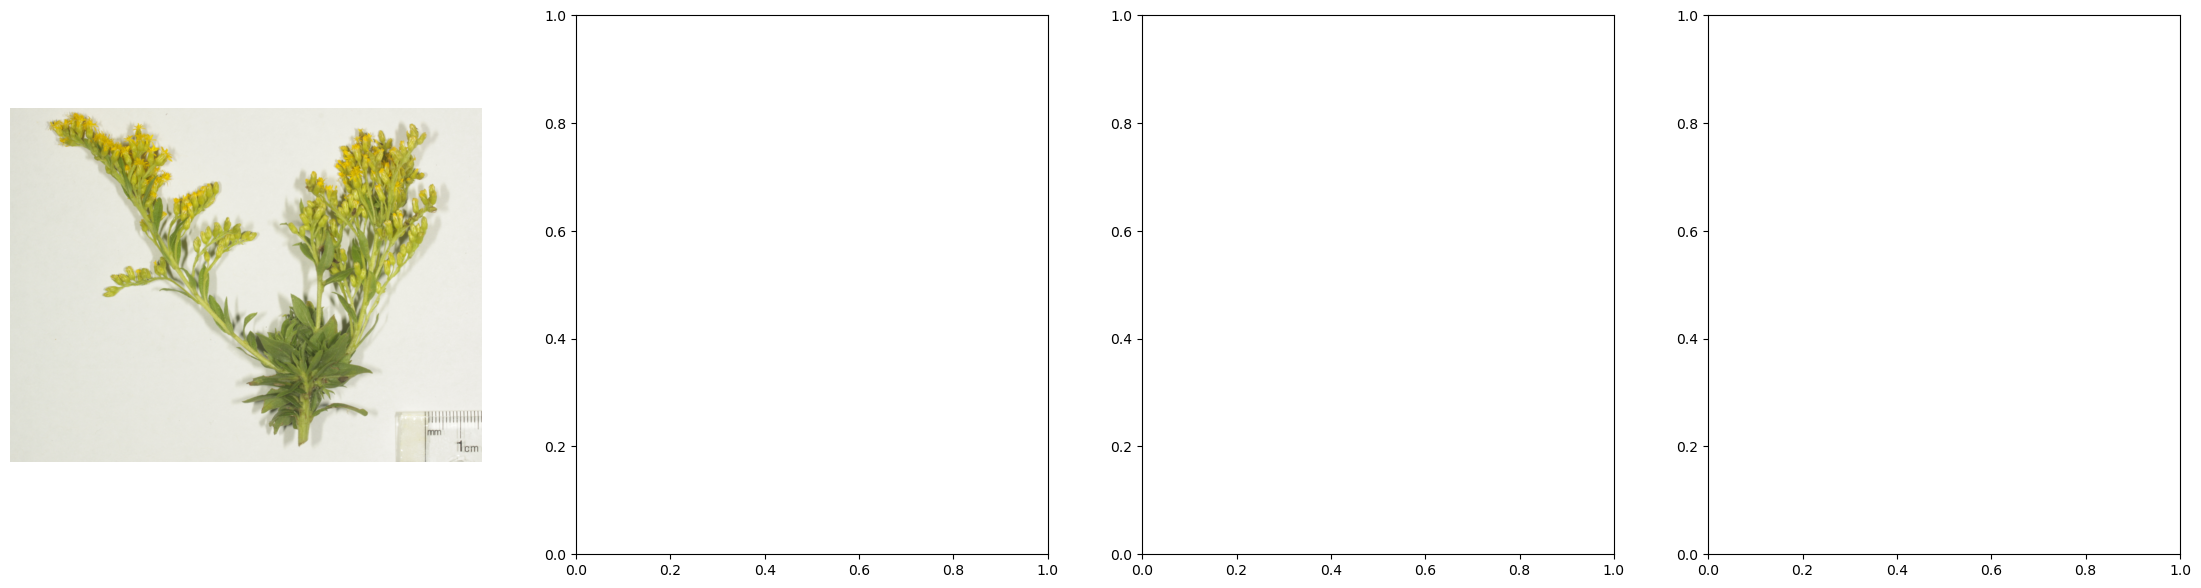

Image: BIOUG85755-H07.7b911bc5, Scale Bar Found: True, Label Present: True, Scale Type: ruler_photo


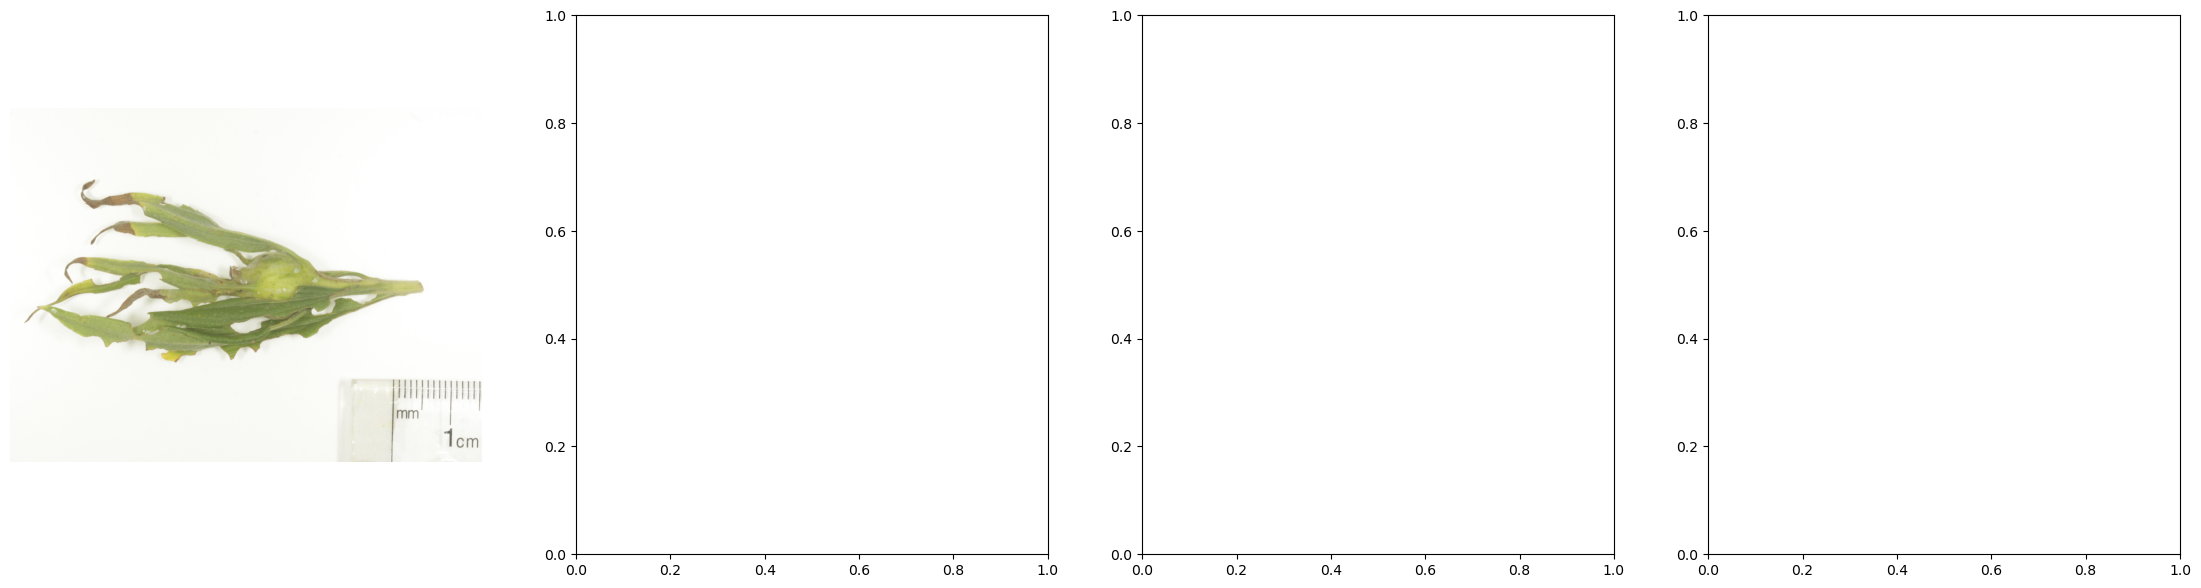

In [31]:
# Error analysis
errors = (
    (detection['scale_bar_found'] != detection['label'].notnull()) |
    ((detection['declared_scale_length'] != detection['value']) & (detection['declared_scale_length'].notnull())) |
    ((detection['units'] != detection['unit']) & (detection['units'].notnull())) |
    ((np.abs(recognition['measured_scale_length'] - recognition['bar_size']) / recognition['bar_size']) > 0.1) |
    (detection['scale_length_flag'] == True)
)
print(f"Number of error cases: {errors.sum()} out of {len(detection)}")

# Visualize errors
def plot_image(image_path, index):
    try:
        plt.subplot(1, 4, index)
        img = plt.imread(image_path)
        plt.imshow(img)
        plt.axis('off')
    except FileNotFoundError: pass

error_cases = detection[errors]
for idx, row in error_cases.iterrows():
    print(f"Image: {idx}, Scale Bar Found: {row['scale_bar_found']}, Label Present: {row['label'] is not None}, Scale Type: {row['type_']}")
    # Load and display image if needed
    plt.figure(figsize=(28, 7))
    plot_image(f"data/annot.nosync/{idx}.jpg", 1)
    plot_image(f"outputs/{idx}_yolo.jpg", 2)
    plot_image(f"outputs/{idx}_ocr.png", 3)
    plot_image(f"outputs/{idx}_scalebar.png", 4)
    plt.show()

In [32]:
# Copy images in error_cases `image` column from the annot folder to a separate error_analysis folder for further inspection
import shutil
os.makedirs('error_analysis', exist_ok=True)
for idx in error_cases.index:
    try:
        shutil.copy(f"data/annot.nosync/{idx}.jpg", f"error_analysis/{idx}.jpg")
    except FileNotFoundError:
        print(f"Image file for {idx} not found, cannot copy.")

In [33]:
#!python src/scaledetection.py --model models/yolov8m_train/weights/best.pt --image_dir data/annot --plot
import json
import os
from pathlib import Path
import sys

import numpy as np
import pandas as pd

sys.path.append(str(Path(os.path.abspath(".")) / "src"))
from src.scaledetection import main as scale_detection_main

%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
_prev_argv = sys.argv
sys.argv = [
	'scaledetection',
	'--model', 'models/yolov8m_train/weights/best.pt',
	'--image_dir', 'error_analysis',
	'--output_dir', 'error_analysis_out',
	'--plot'
]
try:
	scale_results = scale_detection_main()
finally:
	sys.argv = _prev_argv

scale_results

Processing images: 100%|██████████| 3/3 [00:06<00:00,  2.19s/it]
